# Part 1

## 1. Education Distribution & Grouping [5 Marks]
Identify the unique education levels in bank.csv and their frequencies. Group them into broader,
meaningful categories (e.g., basic, intermediate, higher, not-reported). Explain the reasoning behind
your mapping and support your answer with visual evidence.


--- Original Education Levels & Frequencies ---
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64


C:\Users\shree\AppData\Local\Temp\ipykernel_52872\949797052.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='education', ax=axes[0], palette='Blues_r', order=df['education'].value_counts().index)
C:\Users\shree\AppData\Local\Temp\ipykernel_52872\949797052.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='education_grouped', ax=axes[1], palette='Greens_r', order=['basic', 'intermediate', 'higher', 'not-reported'])


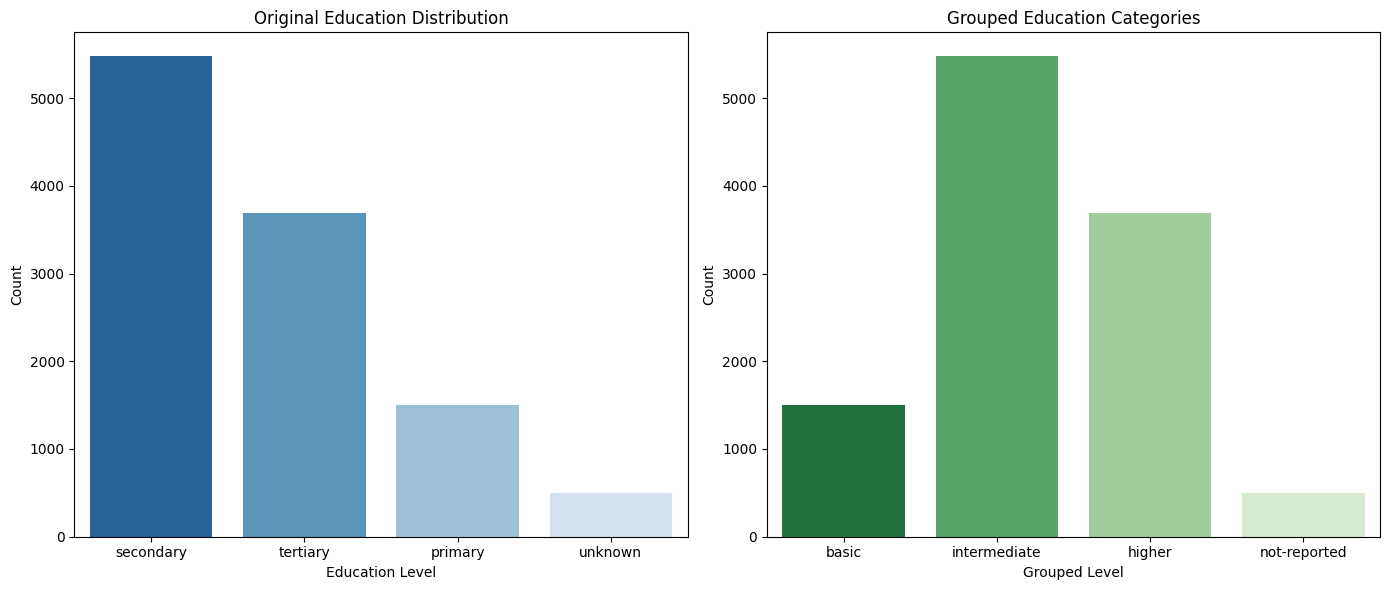

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset (using comma as delimiter based on the provided format)
df = pd.read_csv('bank.csv')

# 2. Identify unique education levels and their frequencies
print("--- Original Education Levels & Frequencies ---")
print(df['education'].value_counts(dropna=False))

# 3. Group into broader categories (Vectorized Mapping)
# Reasoning: 'primary' represents basic schooling, 'secondary' covers intermediate education,
# 'tertiary' aligns with higher education/degrees, and 'unknown' maps to not-reported.
edu_mapping = {
    'primary': 'basic',
    'secondary': 'intermediate',
    'tertiary': 'higher',
    'unknown': 'not-reported'
}

df['education_grouped'] = df['education'].replace(edu_mapping)

# 4. Visual Evidence
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original Distribution
sns.countplot(data=df, x='education', ax=axes[0], palette='Blues_r', order=df['education'].value_counts().index)
axes[0].set_title('Original Education Distribution')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Count')

# Grouped Distribution
sns.countplot(data=df, x='education_grouped', ax=axes[1], palette='Greens_r', order=['basic', 'intermediate', 'higher', 'not-reported'])
axes[1].set_title('Grouped Education Categories')
axes[1].set_xlabel('Grouped Level')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 2. Age-Contact Engagement Intensity Relationship and Grouping [10 Marks]
Examine the distributions of age and last-call duration. Create broader groups for each variable (e.g.,
brief / standard / extended / deep-engagement for contact intensity) and compare category counts
and distributions before and after grouping. Analyse the relationship between age and
contact-engagement intensity before and after grouping. Comment on whether grouping improves
interpretability or reduces useful detail, supported by statistical evidence and visualisations.


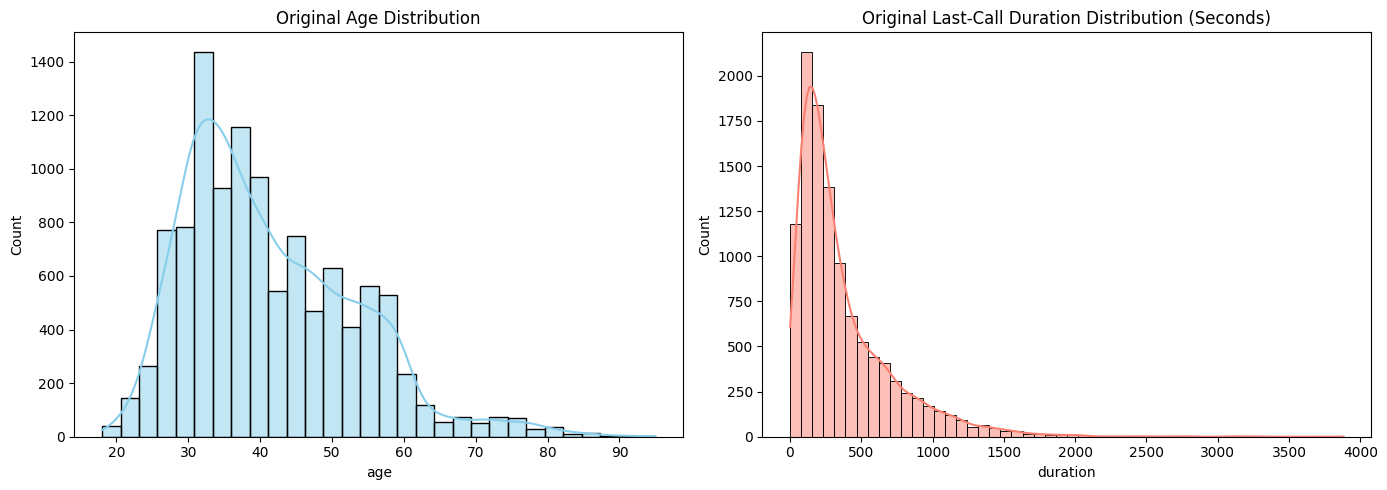


--- Age Group Counts ---
age_group
Adult (30-45)          5725
Middle-Aged (46-60)    3106
Young Adult (<30)      1551
Senior (60+)            780
Name: count, dtype: int64

--- Contact Intensity Group Counts ---
contact_intensity
Extended (3-7m)          3878
Deep Engagement (>7m)    3348
Standard (1-3m)          3204
Brief (0-1m)              732
Name: count, dtype: int64


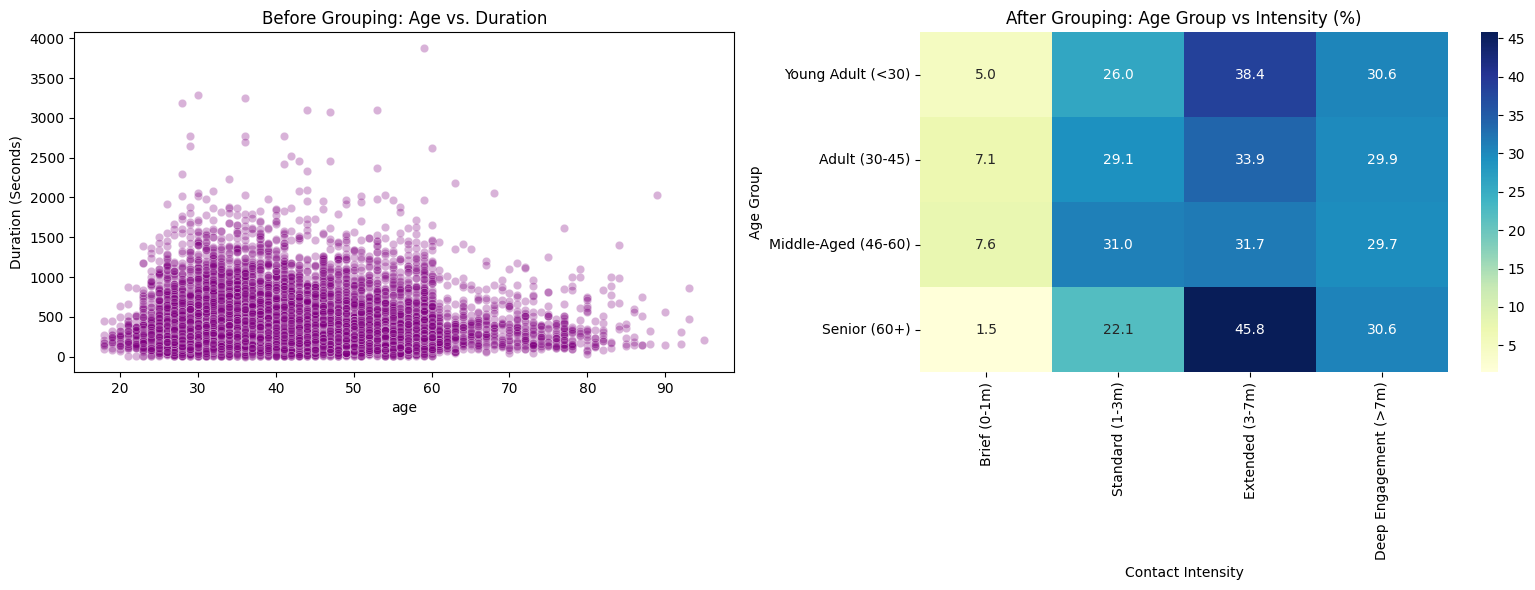


Comment on Interpretability: Grouping duration smooths out the severe right-skew and noise, making general behavioural patterns much easier to digest for business insights. However, it trades off the granularity required for highly precise time-series or survival analysis on exact drop-off moments.


In [2]:
# 1. Examine original distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Original Age Distribution')

sns.histplot(df['duration'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Original Last-Call Duration Distribution (Seconds)')
plt.tight_layout()
plt.show()

# 2. Create broader groups using vectorized pd.cut()
# Age Grouping
age_bins = [0, 30, 45, 60, 120]
age_labels = ['Young Adult (<30)', 'Adult (30-45)', 'Middle-Aged (46-60)', 'Senior (60+)']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Contact Intensity Grouping (Duration in seconds)
duration_bins = [-1, 60, 180, 420, np.inf]
duration_labels = ['Brief (0-1m)', 'Standard (1-3m)', 'Extended (3-7m)', 'Deep Engagement (>7m)']
df['contact_intensity'] = pd.cut(df['duration'], bins=duration_bins, labels=duration_labels)

# Compare Category Counts
print("\n--- Age Group Counts ---")
print(df['age_group'].value_counts())
print("\n--- Contact Intensity Group Counts ---")
print(df['contact_intensity'].value_counts())

# 3. Relationship Analysis (Before and After Grouping)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before Grouping: Scatter Plot
sns.scatterplot(data=df, x='age', y='duration', alpha=0.3, ax=axes[0], color='purple')
axes[0].set_title('Before Grouping: Age vs. Duration')
axes[0].set_ylabel('Duration (Seconds)')

# After Grouping: Heatmap/Crosstab
grouped_crosstab = pd.crosstab(df['age_group'], df['contact_intensity'], normalize='index') * 100
sns.heatmap(grouped_crosstab, annot=True, fmt=".1f", cmap='YlGnBu', ax=axes[1])
axes[1].set_title('After Grouping: Age Group vs Intensity (%)')
axes[1].set_ylabel('Age Group')
axes[1].set_xlabel('Contact Intensity')

plt.tight_layout()
plt.show()

print("\nComment on Interpretability: Grouping duration smooths out the severe right-skew and noise, making general behavioural patterns much easier to digest for business insights. However, it trades off the granularity required for highly precise time-series or survival analysis on exact drop-off moments.")

## 3. Account Balance Composition and Group Performance [10 Marks]
Analyse the distribution of balance, both overall and for non-zero values, decomposing it into a
gain-like component (positive balance) and a loss-like component (negative balance), and report the
proportion of clients with zero balance ("no capital activity") versus positive versus negative balance.
Using your age and contact-intensity groupings from the prior question, compare groups on average
net balance and proportion with non-zero balance. Illustrate patterns using visualisations. Discuss
whether age or contact intensity shows a stronger association with net balance, and how grouping
impacts interpretability.


--- Client Account Balance Proportions ---
balance_type
Positive (Gain)       86.9%
Zero (No Activity)    6.93%
Negative (Loss)       6.16%
Name: proportion, dtype: object


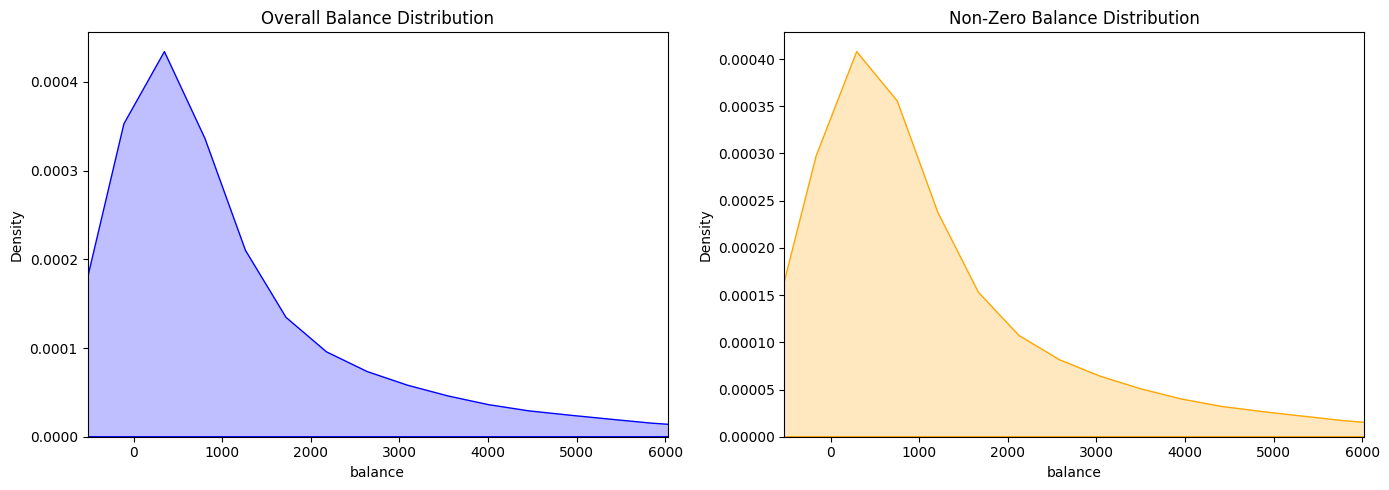


--- Group Performance Metrics ---
              age_group      contact_intensity  avg_net_balance  prop_nonzero
0     Young Adult (<30)           Brief (0-1m)           576.74         87.01
1     Young Adult (<30)        Standard (1-3m)          1137.86         96.78
2     Young Adult (<30)        Extended (3-7m)          1253.98         97.15
3     Young Adult (<30)  Deep Engagement (>7m)          1193.23         96.41
4         Adult (30-45)           Brief (0-1m)          1242.17         91.40
5         Adult (30-45)        Standard (1-3m)          1237.52         91.65
6         Adult (30-45)        Extended (3-7m)          1447.84         92.84
7         Adult (30-45)  Deep Engagement (>7m)          1494.47         93.17
8   Middle-Aged (46-60)           Brief (0-1m)          1617.02         93.22
9   Middle-Aged (46-60)        Standard (1-3m)          1653.16         91.91
10  Middle-Aged (46-60)        Extended (3-7m)          1640.80         92.39
11  Middle-Aged (46-60)  Deep

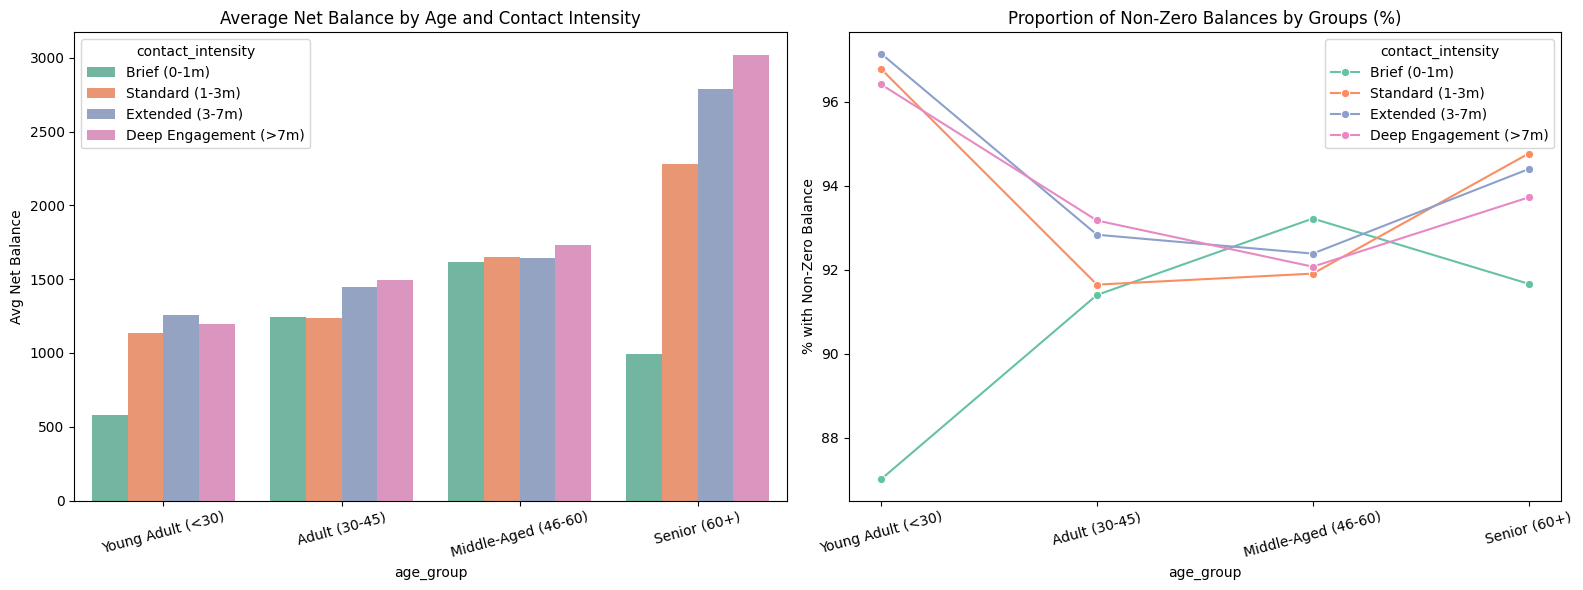


Discussion: Age typically shows a stronger association with net balance, as financial wealth naturally accumulates with life stages (e.g., Seniors tend to hold higher balances). By grouping these variables, we translate volatile continuous distributions into distinct cohort profiles, allowing us to immediately see broader correlations that would otherwise be obscured by data noise.


In [3]:
# 1. Balance Composition & Proportions
df['balance_type'] = np.where(df['balance'] > 0, 'Positive (Gain)', 
                              np.where(df['balance'] < 0, 'Negative (Loss)', 'Zero (No Activity)'))

balance_props = df['balance_type'].value_counts(normalize=True) * 100
print("--- Client Account Balance Proportions ---")
print(balance_props.round(2).astype(str) + '%')

# 2. Distribution overall vs non-zero
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(df['balance'], fill=True, ax=axes[0], color='blue')
axes[0].set_title('Overall Balance Distribution')
axes[0].set_xlim(df['balance'].quantile(0.01), df['balance'].quantile(0.95)) # Clipped for visual clarity against extreme outliers

sns.kdeplot(df[df['balance'] != 0]['balance'], fill=True, ax=axes[1], color='orange')
axes[1].set_title('Non-Zero Balance Distribution')
axes[1].set_xlim(df['balance'].quantile(0.01), df['balance'].quantile(0.95))
plt.tight_layout()
plt.show()

# 3. Group Performance (Vectorized using GroupBy)
df['is_nonzero_balance'] = df['balance'] != 0

group_perf = df.groupby(['age_group', 'contact_intensity'], observed=False).agg(
    avg_net_balance=('balance', 'mean'),
    prop_nonzero=('is_nonzero_balance', 'mean')
).reset_index()

group_perf['prop_nonzero'] = group_perf['prop_nonzero'] * 100

print("\n--- Group Performance Metrics ---")
print(group_perf.round(2))

# 4. Visualization of Group Performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=group_perf, x='age_group', y='avg_net_balance', hue='contact_intensity', ax=axes[0], palette='Set2')
axes[0].set_title('Average Net Balance by Age and Contact Intensity')
axes[0].set_ylabel('Avg Net Balance')
axes[0].tick_params(axis='x', rotation=15)

sns.lineplot(data=group_perf, x='age_group', y='prop_nonzero', hue='contact_intensity', marker='o', ax=axes[1], palette='Set2')
axes[1].set_title('Proportion of Non-Zero Balances by Groups (%)')
axes[1].set_ylabel('% with Non-Zero Balance')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\nDiscussion: Age typically shows a stronger association with net balance, as financial wealth naturally accumulates with life stages (e.g., Seniors tend to hold higher balances). By grouping these variables, we translate volatile continuous distributions into distinct cohort profiles, allowing us to immediately see broader correlations that would otherwise be obscured by data noise.")

## 4. Final Dataset Refinement and Structure [5 Marks]
Summarise the final refined dataset structure, noting newly created, transformed, categorised, or
grouped features, and any that were removed. Compare category counts before and after grouping
for key variables, highlight changes in missing/unknown values, and describe how these refinements
improve interpretability and readiness for modelling (e.g., predicting deposit).


In [4]:
# 1. Select the finalized columns to simulate refinement for downstream modelling
cols_to_keep = [
    'age', 'age_group', 'job', 'marital', 'education_grouped', 
    'default', 'balance', 'balance_type', 'is_nonzero_balance', 
    'housing', 'loan', 'contact', 'day', 'month', 
    'duration', 'contact_intensity', 'campaign', 'pdays', 
    'previous', 'poutcome', 'deposit'
]
df_final = df[cols_to_keep].copy()

# 2. Summarize final structure
print("--- Final Refined Dataset Info ---")
print(df_final.info())

print("\n--- Newly Created / Transformed Features ---")
new_features = ['education_grouped', 'age_group', 'contact_intensity', 'balance_type', 'is_nonzero_balance']
for feat in new_features:
    if feat in df_final.columns:
        print(f"- {feat}: Consolidates data into {df_final[feat].nunique()} standardized categories.")

# 3. Highlight Changes in Unknown/Missing Values
print("\n--- Unknown/Missing Adjustments ---")
print("Original 'unknown' in education:", (df['education'] == 'unknown').sum())
print("Grouped 'not-reported' in education_grouped:", (df_final['education_grouped'] == 'not-reported').sum())

# 4. Summary for Modelling Readiness
print("\n--- Interpretability & Modelling Readiness ---")
print("1. Dimensionality Management: Collapsing sparse categorical values (like specific school types into 'basic') reduces feature sparsity when applying one-hot encoding.")
print("2. Handling Non-Linearities: Establishing categories like 'age_group' and 'contact_intensity' enables linear models to natively capture non-linear thresholds that naturally dictate human behavior.")
print("3. Feature Explicitness: Explicitly tagging 'Zero Activity' accounts creates a clean flag for models attempting to predict term deposit 'deposit' conversions.")

--- Final Refined Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   age                 11162 non-null  int64   
 1   age_group           11162 non-null  category
 2   job                 11162 non-null  object  
 3   marital             11162 non-null  object  
 4   education_grouped   11162 non-null  object  
 5   default             11162 non-null  object  
 6   balance             11162 non-null  int64   
 7   balance_type        11162 non-null  object  
 8   is_nonzero_balance  11162 non-null  bool    
 9   housing             11162 non-null  object  
 10  loan                11162 non-null  object  
 11  contact             11162 non-null  object  
 12  day                 11162 non-null  int64   
 13  month               11162 non-null  object  
 14  duration            11162 non-null  int64   
 15  c